# Neural Network from Scratch (NumPy)
## Task 7 - MVC Project

- Dataset: MNIST
- Architecture: 784 → 128 → 64 → 10
- Activation: Sigmoid
- Loss: MSE
- Optimizer: Mini-batch Gradient Descent

In [2]:
#imports

import numpy as np
import matplotlib.pyplot as plt

In [3]:
#Load Dataset (LOCAL FILE)
data = np.load('mnist.npz')

X_train = data['x_train'].reshape(-1, 784) / 255.0
Y_train = data['y_train']

X_test = data['x_test'].reshape(-1, 784) / 255.0
Y_test = data['y_test']

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (60000, 784)
Test shape: (10000, 784)


In [4]:
#One-Hot Encoding

def one_hot(y, num_classes=10):
    return np.eye(num_classes)[y]

Y_train_oh = one_hot(Y_train)
Y_test_oh = one_hot(Y_test)

In [5]:
#Initialize Weights

np.random.seed(42)

W1 = np.random.uniform(-0.5, 0.5, (784, 128))
b1 = np.zeros((1, 128))

W2 = np.random.uniform(-0.5, 0.5, (128, 64))
b2 = np.zeros((1, 64))

W3 = np.random.uniform(-0.5, 0.5, (64, 10))
b3 = np.zeros((1, 10))

In [6]:
#Sigmoid Functions

def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a):
    return a * (1 - a)

In [7]:
# Forward Pass

def forward_pass(X, W1, b1, W2, b2, W3, b3):

    Z1 = X @ W1 + b1
    A1 = sigmoid(Z1)

    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)

    Z3 = A2 @ W3 + b3
    A3 = sigmoid(Z3)

    return Z1, A1, Z2, A2, Z3, A3

In [8]:
#MSE Loss

def mse_loss(Y_true, Y_pred):
    return np.mean((Y_true - Y_pred) ** 2)

In [9]:
# Backpropagation

def backpropagation(X, Y_true, Z1, A1, Z2, A2, Z3, A3, W1, W2, W3):

    m = X.shape[0]

    delta3 = -2 * (Y_true - A3) * sigmoid_derivative(A3)
    dW3 = A2.T @ delta3 / m
    db3 = np.sum(delta3, axis=0, keepdims=True) / m

    delta2 = (delta3 @ W3.T) * sigmoid_derivative(A2)
    dW2 = A1.T @ delta2 / m
    db2 = np.sum(delta2, axis=0, keepdims=True) / m

    delta1 = (delta2 @ W2.T) * sigmoid_derivative(A1)
    dW1 = X.T @ delta1 / m
    db1 = np.sum(delta1, axis=0, keepdims=True) / m

    return dW1, db1, dW2, db2, dW3, db3

In [10]:
# Update Weights

def update_weights(W1, b1, W2, b2, W3, b3,
                   dW1, db1, dW2, db2, dW3, db3,
                   learning_rate):

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    W3 -= learning_rate * dW3
    b3 -= learning_rate * db3

    return W1, b1, W2, b2, W3, b3

In [11]:
# Training Loop

learning_rate = 0.1
epochs = 20
batch_size = 32

loss_history = []

for epoch in range(epochs):

    idx = np.random.permutation(X_train.shape[0])
    X_shuf = X_train[idx]
    Y_shuf = Y_train_oh[idx]

    for start in range(0, X_train.shape[0], batch_size):

        X_batch = X_shuf[start:start+batch_size]
        Y_batch = Y_shuf[start:start+batch_size]

        Z1,A1,Z2,A2,Z3,A3 = forward_pass(X_batch, W1,b1,W2,b2,W3,b3)

        loss = mse_loss(Y_batch, A3)

        dW1,db1,dW2,db2,dW3,db3 = backpropagation(
            X_batch, Y_batch, Z1,A1,Z2,A2,Z3,A3, W1,W2,W3)

        W1,b1,W2,b2,W3,b3 = update_weights(
            W1,b1,W2,b2,W3,b3,
            dW1,db1,dW2,db2,dW3,db3, learning_rate)

    _,_,_,_,_,A3_full = forward_pass(X_train,W1,b1,W2,b2,W3,b3)
    epoch_loss = mse_loss(Y_train_oh, A3_full)

    loss_history.append(epoch_loss)
    print(f"Epoch {epoch+1}: Loss = {epoch_loss:.4f}")

Epoch 1: Loss = 0.0296
Epoch 2: Loss = 0.0208
Epoch 3: Loss = 0.0172
Epoch 4: Loss = 0.0153
Epoch 5: Loss = 0.0138
Epoch 6: Loss = 0.0127
Epoch 7: Loss = 0.0119
Epoch 8: Loss = 0.0111
Epoch 9: Loss = 0.0105
Epoch 10: Loss = 0.0100
Epoch 11: Loss = 0.0095
Epoch 12: Loss = 0.0091
Epoch 13: Loss = 0.0088
Epoch 14: Loss = 0.0084
Epoch 15: Loss = 0.0081
Epoch 16: Loss = 0.0078
Epoch 17: Loss = 0.0076
Epoch 18: Loss = 0.0073
Epoch 19: Loss = 0.0071
Epoch 20: Loss = 0.0069


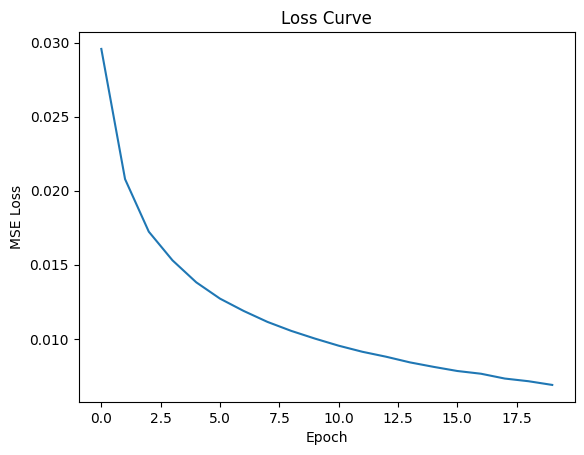

In [12]:
# Loss Curve

plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Loss Curve")
plt.show()

In [13]:
# Test Accuracy

_,_,_,_,_,A3_test = forward_pass(X_test, W1,b1,W2,b2,W3,b3)

predictions = np.argmax(A3_test, axis=1)
accuracy = np.mean(predictions == Y_test) * 100

print("Test Accuracy:", accuracy)

Test Accuracy: 95.54


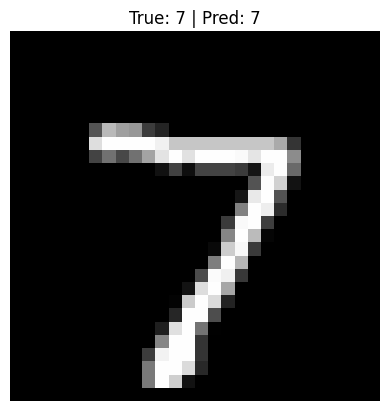

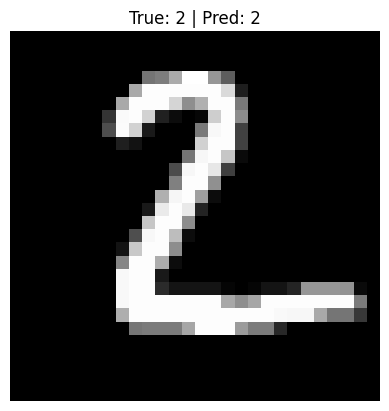

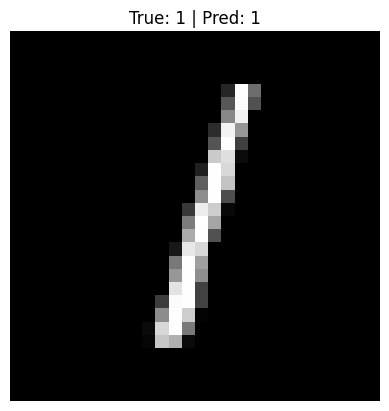

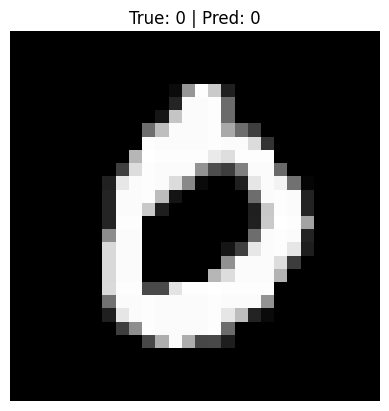

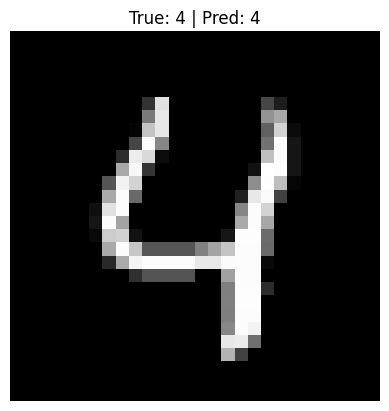

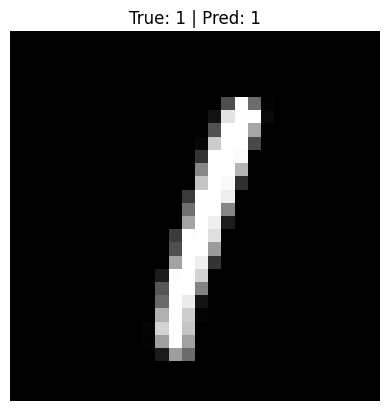

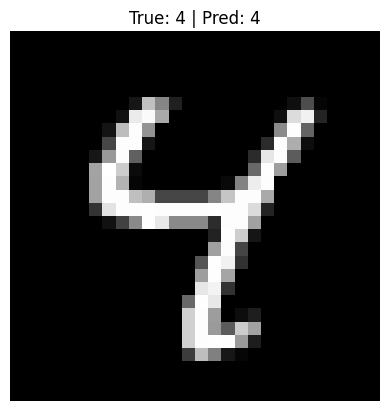

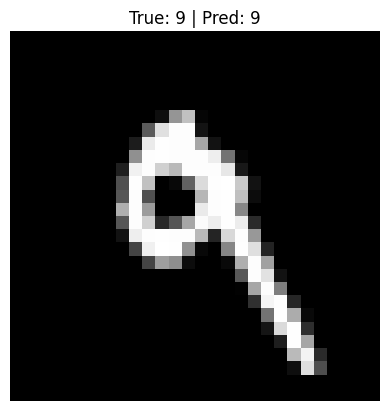

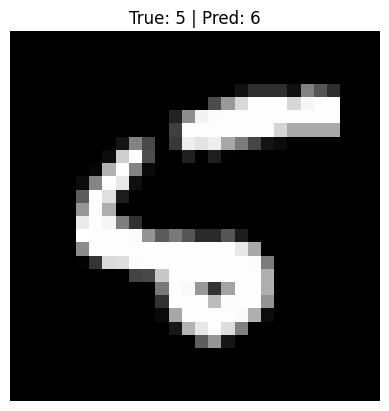

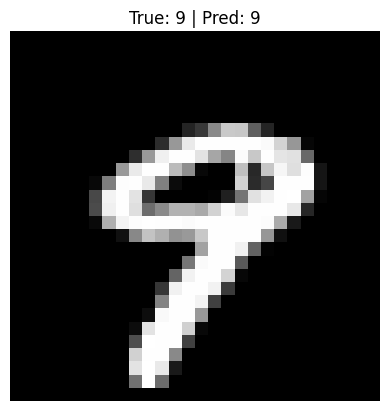

In [14]:
# Sample Predictions

for i in range(10):
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(f"True: {Y_test[i]} | Pred: {predictions[i]}")
    plt.axis('off')
    plt.show()

## Observations

- Loss decreases over epochs → model is learning
- Accuracy improves → correct predictions increase
- Mini-batch helps stabilize training